In [ ]:
import warnings
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from os.path import join
from IPython import display
from sklearn.datasets import load_digits
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, v_measure_score # и другие метрики
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN # а также другие алгоритмы

In [ ]:
DATA_PATH = "data"
plt.rcParams["figure.figsize"] = 12, 9
sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

SEED = 111
random.seed(SEED)
np.random.seed(SEED)

### Задание 1. Реализация Kmeans

5 баллов

В данном задании вам предстоит написать код класса `MyKMeans`.

Сгенерируем простой набор данных, 400 объектов и 2 признака (чтобы все быстро работало и можно было легко нарисовать):

In [ ]:
X, true_labels = make_blobs(400, 2, centers=[[0, 0], [-4, 0], [3.5, 3.5], [3.5, -2.0]])

`visualize_clusters` - по данным и меткам кластеров будет рисовать их и разукрашивать:

In [ ]:
def visualize_clusters(X, labels):
    """
    Функция для визуализации кластеров
        :param X: таблица объекты х признаки
        :param labels: np.array[n_samples] - номера кластеров
    """

    unique_labels = np.sort(np.unique(labels))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels,
                    palette="colorblind", legend=False,
                    hue_order=unique_labels)
    plt.xlabel("$X_1$", fontsize=18)
    plt.ylabel("$X_2$", fontsize=18)

    for label in labels:
        center = X[(labels == label)].mean(axis=0)
        plt.scatter(center[0], center[1], s=80, c="#201F12", marker=(5, 2))

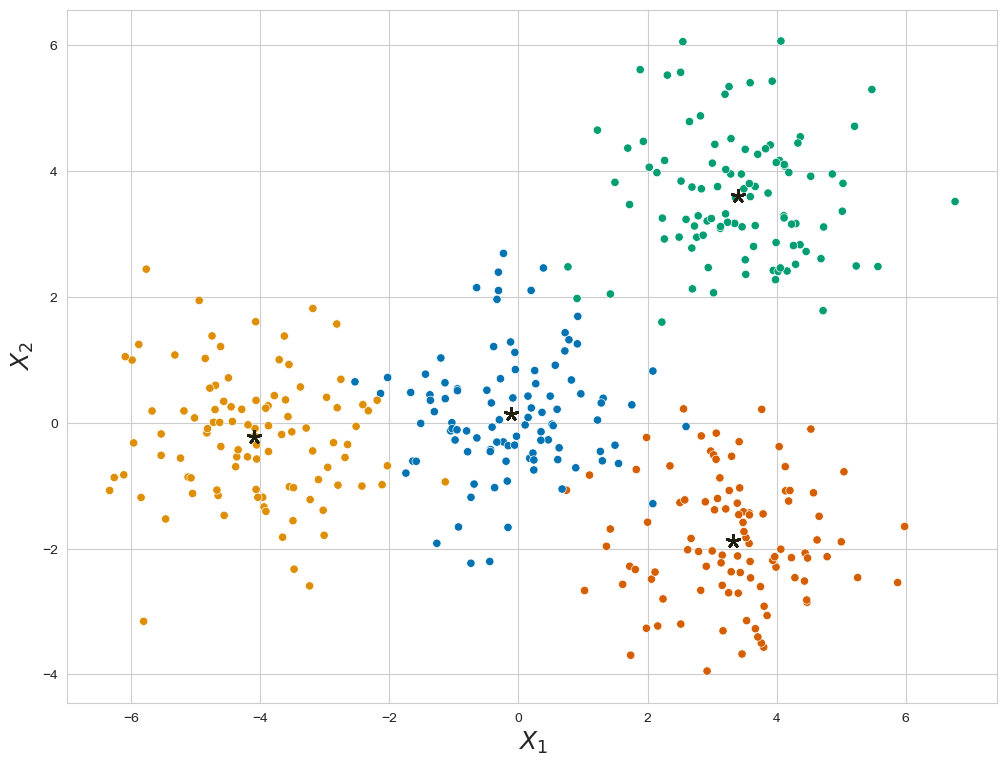

In [ ]:
visualize_clusters(X, true_labels)

Класс `MyKMeans`, который будет реализовывать алгоритм кластеризации K-средних.

1. Выбераем число кластеров (K)
2. Случайно инициализируем K точек (или выбираем из данных), это будут начальные центры наших кластеров
3. Далее для каждого объекта считаем расстояние до всех кластеров и присваиваем ему метку ближайщего
4. Далее для каждого кластера считаем "центр масс" (среднее значение для каждого признака по всем объектам кластера)
5. Этот "центр масс" становится новым центром кластера
6. Повторяем п.3, 4, 5 заданное число итераций или до сходимости


Реализуйте методы:
* `_calculate_distance(X, centroid)` - вычисляет Евклидово расстояние от всех объектов в `Х` до заданного центра кластера (`centroid`)
* `predict(X)` - для каждого элемента из `X` возвращает номер кластера, к которому относится данный элемент

In [1]:
class MyKMeans:
    def __init__(self, n_clusters, init="random", max_iter=300, visualize=False):
        """
        Конструктор класса MyKMeans
            :param n_clusters: число кластеров
            :param init: способ инициализации центров кластеров
                'random' - генерирует координаты случайно из нормального распределения
                'sample' - выбирает центроиды случайно из объектов выборки
            :param max_iter: заданное число итераций
                (мы не будем реализовывать другой критерий остановки)
            :param visualize: рисовать ли кластеры и их центроиды в процессе работы
                код будет работать сильно дольше, но красиво...
        """

        assert init in ["random", "sample"], f"Неизвестный метод инициализации {init}"
        self.n_clusters = n_clusters
        self.init = init
        self.max_iter = max_iter
        self.centroids = None
        self.visualize = visualize


    def fit(self, X):
        """
        Подбирает оптимальные центры кластеров
            :param X: наши данные (n_samples, n_features)
        :return self: все как в sklearn
        """

        n_samples, n_features = X.shape

        # Инициализация центров кластеров
        if self.init == "random":
            centroids = np.random.randn(self.n_clusters, n_features)
        elif self.init == "sample":
            centroids_idx = np.random.choice(np.arange(n_samples),
                                             size=self.n_clusters,
                                             replace=False)
            centroids = X[centroids_idx]

        # Итеративно двигаем центры
        for _ in range(self.max_iter):
            # Посчитаем расстояния для всех объектов до каждого центроида
            dists = []
            for centroid in centroids:
                dists.append(self._calculate_distance(X, centroid))
            dists = np.concatenate(dists, axis=1)
            # Для каждого объекта найдем, к какому центроиду он ближе
            cluster_labels = np.argmin(dists, axis=1)

            # Пересчитаем центр масс для каждого кластера
            centroids = []
            for label in np.sort(np.unique(cluster_labels)):
                center = X[(cluster_labels == label)].mean(axis=0)
                centroids.append(center)

            # Отрисуем точки, покрасим по меткам кластера, а также изобразим центроиды
            if self.visualize:
                visualize_clusters(X, cluster_labels)
                display.clear_output(wait=True)
                display.display(plt.gcf())
                plt.close()

        self.centroids = np.array(centroids)

        return self


    def predict(self, X):
        """
        Для каждого X возвращает номер кластера, к которому он относится
            :param X: наши данные (n_samples, n_features)
        :return cluster_labels: метки кластеров
        """

        dists = []
        for centroid in self.centroids:
            dists.append(self._calculate_distance(X, centroid))
        dists = np.concatenate(dists, axis=1)
        cluster_labels = np.argmin(dists, axis=1)

        return cluster_labels


    def _calculate_distance(self, X, centroid):
        """
        Вычисляет Евклидово расстояние от всех объектов в Х до заданного центра кластера (centroid)
            :param X: наши данные (n_samples, n_features)
            :param centroid: координаты центра кластера
        :return dist: расстояния от всех X до центра кластера
        """

        return np.sum(np.square(X - centroid), axis=1).reshape(-1, 1)




Обучите `MyKMeans`

In [2]:
klasterer = MyKMeans(n_clusters=4,max_iter=50, visualize=True)
klasterer.fit(X)
#klasterer.predict


NameError: name 'X' is not defined

### <font color='red'>  Predict testing:

In [ ]:
model = klasterer

dists = []
for centroid in model.centroids:
    dists.append(model._calculate_distance(X, centroid))
dists = np.concatenate(dists, axis=1)
test_labels = np.argmin(dists, axis=1)

pred_labels = model.predict(X)

np.array_equal(test_labels.ravel(), pred_labels.ravel())

True

### Задание 2. Подбираем лучшую иерархическую кластеризацию

5 баллов

Функция `algorithm_selection`, которая будет на основании переданных ей:

* метрик расстояния (можно брать все, что было на лекциях, минимум 4)
* параметра `linkage` ('average', 'single', 'complete')
* и метрик качества кластеризации ('Homogeneity', 'Completeness', 'V-measure', 'Silhouette')

будет выводить итоговую таблицу, в которую войдут столбцы:
* distance (метрика расстояния)
* linkage (алгоритм иерархической кластеризации)
* homogenity
* completeness
* v_measure
* silhouette

В результате по этой таблице, нужно сделать вывод о том, какой алгоритм кластеризации и с какими гиперпараметрами лучше всего сработал.

Загрузим наши данные:

In [ ]:
data = load_digits()
X, y = data.data, data.target

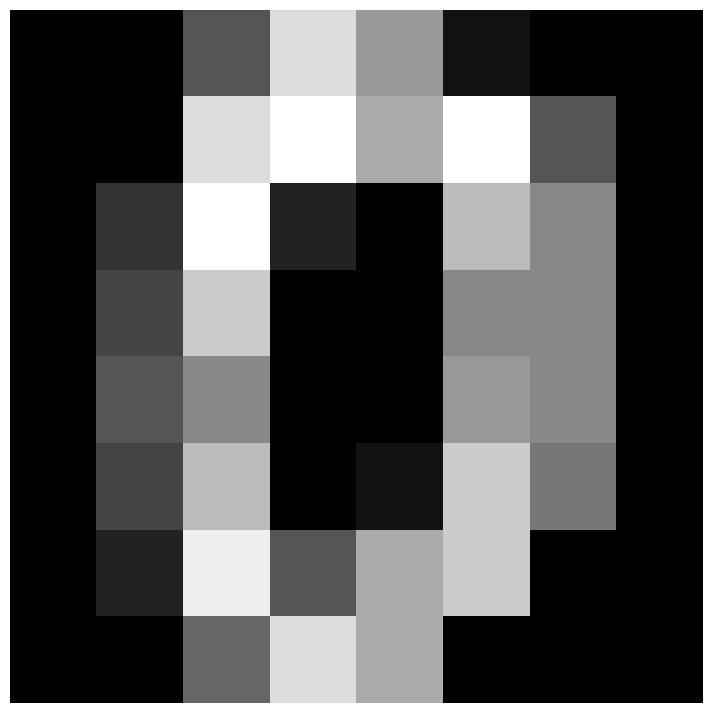

In [ ]:
plt.imshow(X[0].reshape(8, 8).astype(int), cmap="gray")
plt.axis("off");

In [ ]:
def algorithm_selection(X, y=None, n_clusters=10, distances = ['euclidean', 'manhattan'], algorithms = ['average', 'single'], metrics=[homogeneity_score, completeness_score, v_measure_score, silhouette_score]):
    """
    Для заданных алгоримов кластеризации и гиперпараметров
    считает различные метрики кластеризации
        :param X: наши данные (n_samples, n_features)
        :param distances: список возможных метрик расстояния
        :param algorithm: параметр linkage ('average', 'single', 'complete')
        :param metrics: список возможных метрик качества кластеризации
    :return compare_dataframe: таблица с метриками кластеризации
    """
    #compare_dataframe = pd.DataFrame({'Distances': distances, 'Algorithm': algorithm, })
    if isinstance(y, np.ndarray):
        compare_dict = {'distance': [], 'linkage': [], 'homogenity': [], 'completeness': [], 'v_measure': [], 'silhouette': []}
    else:
        compare_dict = {'distance': [], 'linkage': [], 'silhouette': []}

    for algorithm in algorithms:
        for dist in distances:
            agg = AgglomerativeClustering(n_clusters=n_clusters, metric=dist, linkage=algorithm)
            agg.fit(X)
            labels = agg.labels_

            # homogeneity_score(y, labels)        higher is better
            # completeness_score(y, labels)     higher is better
            # v_measure_score(y, labels)            higher is better
            # silhouette_score(X, labels)         The best value is 1 and the worst value is -1

            compare_dict['distance'].append(dist)
            compare_dict['linkage'].append(algorithm)
            if isinstance(y, np.ndarray):
                compare_dict['homogenity'].append(homogeneity_score(y, labels))
                compare_dict['completeness'].append(completeness_score(y, labels))
                compare_dict['v_measure'].append(v_measure_score(y, labels))
            compare_dict['silhouette'].append(silhouette_score(X, labels))

    compare_dataframe = pd.DataFrame(compare_dict).groupby(['distance'], group_keys=True).apply(lambda x: x)
    return compare_dataframe.drop(columns= ['distance'])

In [ ]:
distances = ['euclidean', 'manhattan', 'cosine', 'minkowski', 'jaccard']
algo = ['average', 'single', 'complete']
#res =
algorithm_selection(X, y, 10, distances, algo)

,linkage,homogenity,completeness,v_measure,silhouette
0,average,0.655393,0.782342,0.713263,0.146625
1,average,0.566751,0.778942,0.656117,0.089217
2,average,0.648268,0.808762,0.719676,0.129526
3,average,0.655393,0.782342,0.713263,0.146625
4,average,0.026260,0.179269,0.045809,-0.137721
5,single,0.005056,0.273755,0.009929,-0.133621
6,single,0.005102,0.276237,0.010019,-0.166627
7,single,0.005050,0.273389,0.009916,-0.158250
8,single,0.005056,0.273755,0.009929,-0.133621
9,single,0.005014,0.271451,0.009846,-0.120632


Лучше всего с данной задачей справляются алгоритмы:

- distance: cosine, linkage: average
- distance: euclidean, linkage: average
- distance: minkowski, linkage: average

Так как они имеют более высокие показатели метрик

### Задание 3. Аннотация клеточных типов



В этом задании вам предстоит применять полученные знания о кластеризации для аннотации данных, полученных при помощи проточной цитометрии. Каждая строка в данных это одна клетка, столбцы **FSC-A**, **SSC-A** косвенным образом свидетельствуют о размере клеток, остальные показывают интенсивность флуоресценции различных поверхностных маркеров. Ваша задача определить для каждой клетки, к какому типу она относится.

#### EDA


In [ ]:
fc_data = pd.read_csv(join(DATA_PATH, "flow_c_data.csv"), index_col=0)

In [ ]:
fc_data.head()

,FSC-A,SSC-A,HLA-DR,CD3,CD45,CD14,CD56,CD19,CD11c
0,0.722199,0.154232,0.494449,0.512853,4.057328,1.019255,4.007273,-1.406912,0.384406
1,0.751073,0.114618,4.671924,0.822042,4.933149,0.159388,-0.216407,6.034845,0.577039
2,1.108188,0.150011,-0.422857,4.006353,5.616384,0.519223,0.783077,-0.318668,-0.493832
3,0.553310,0.119929,0.345968,3.332310,5.260935,1.481229,0.264846,0.694883,3.416960
4,0.774884,0.076984,4.984963,0.885501,4.562367,0.217117,0.086279,5.563345,0.471591


In [ ]:
fc_data.shape

(10000, 9)

In [ ]:
fc_data.isna().sum()

FSC-A     0
SSC-A     0
HLA-DR    0
CD3       0
CD45      0
CD14      0
CD56      0
CD19      0
CD11c     0
dtype: int64

In [ ]:
fc_data.describe()

,FSC-A,SSC-A,HLA-DR,CD3,CD45,CD14,CD56,CD19,CD11c
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.962458,0.165415,1.791579,3.280391,5.169845,1.097182,0.412223,1.219683,0.569898
std,0.500012,0.190773,2.027281,2.112079,0.518247,1.375876,1.176967,2.285305,1.502445
min,0.144786,0.021657,-7.634172,-2.517639,-8.329666,-8.833883,-12.358701,-9.640775,-11.085437
25%,0.798804,0.105550,0.275056,1.401943,4.922227,0.389746,-0.195978,-0.146948,-0.498781
50%,0.908574,0.130543,1.194313,4.373660,5.234119,0.672853,0.053267,0.244121,0.272297
75%,1.052034,0.162536,3.696976,4.842212,5.481218,1.065076,0.378576,0.908374,1.220576
max,42.954485,15.460997,12.946668,13.844391,13.710922,6.294236,6.461899,7.208721,6.840864


Column: FSC-A, found 538 outliers
Column: SSC-A, found 1132 outliers
Column: HLA-DR, found 12 outliers
Column: CD3, found 3 outliers
Column: CD45, found 182 outliers
Column: CD14, found 1136 outliers
Column: CD56, found 1337 outliers
Column: CD19, found 2071 outliers
Column: CD11c, found 515 outliers


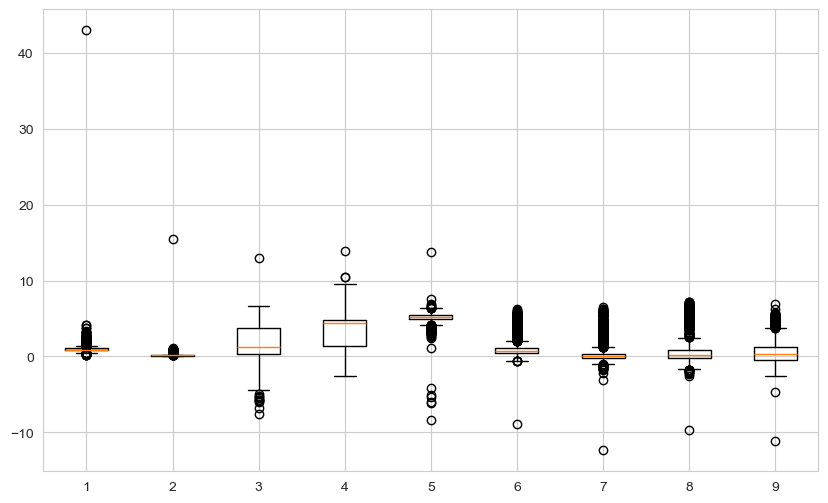

In [ ]:
def find_outliers_IQR(df):

    q1=df.quantile(0.25)
    q3=df.quantile(0.75)
    IQR=q3-q1
    outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]

    return outliers


out = {}
for col in fc_data.columns:
    o = find_outliers_IQR(fc_data[col])
    out[col] = o
    print(f'Column: {col}, found {len(o)} outliers')

plt.figure(figsize=(10, 6))
plt.boxplot(fc_data)
plt.show()

In [ ]:
pd.DataFrame(out).dropna(axis=0, how='any')

#Это значения, которые являются выбросами по всем параметрам, их однозначно удаляем
to_drop = []
to_drop += list(pd.DataFrame(out).dropna(axis=0, how='any').index)


In [ ]:
minimum = fc_data['HLA-DR'].quantile(0.25)-1.5*(fc_data['HLA-DR'].quantile(0.75)-fc_data['HLA-DR'].quantile(0.25))
maximum = fc_data['CD3'].quantile(0.75)+1.5*(fc_data['CD3'].quantile(0.75)-fc_data['CD3'].quantile(0.25))
critical_outliers = fc_data[fc_data[((minimum < fc_data) & (fc_data < maximum))].isna().any(1)]

critical_outliers

,FSC-A,SSC-A,HLA-DR,CD3,CD45,CD14,CD56,CD19,CD11c
699,1.922709,0.254377,-4.921411,8.847605,5.307502,1.571615,-0.494133,2.414185,2.736853
1505,1.598177,0.335609,-5.232391,9.016271,5.619268,2.253614,-1.210020,3.196415,3.856270
1590,4.092169,0.657198,-7.634172,10.452256,-8.329666,3.199919,-3.079160,5.233442,-4.670057
1767,2.667779,0.507324,-6.046983,9.482278,-6.055190,2.200656,-1.664012,3.808203,3.141091
1884,2.178018,0.239796,-5.911095,9.337276,-6.186435,1.975513,-1.614532,3.496127,3.616438
3918,2.600903,0.552938,-5.790973,9.213162,-5.326229,1.876560,-1.172034,3.439671,3.192194
5352,3.131965,0.470987,-5.772591,9.374428,-5.097903,2.391261,-1.162506,3.418326,4.034943
5526,1.520960,0.309858,-5.458917,9.177510,-4.156778,1.853277,3.755729,2.979899,4.396361
5843,42.954485,15.460997,12.946668,13.844391,13.710922,-8.833883,-12.358701,-9.640775,-11.085437
6488,2.202049,0.356282,-5.799322,9.256607,3.406094,1.942709,-1.626368,3.563598,4.060589


In [ ]:
to_drop += list(critical_outliers.index)

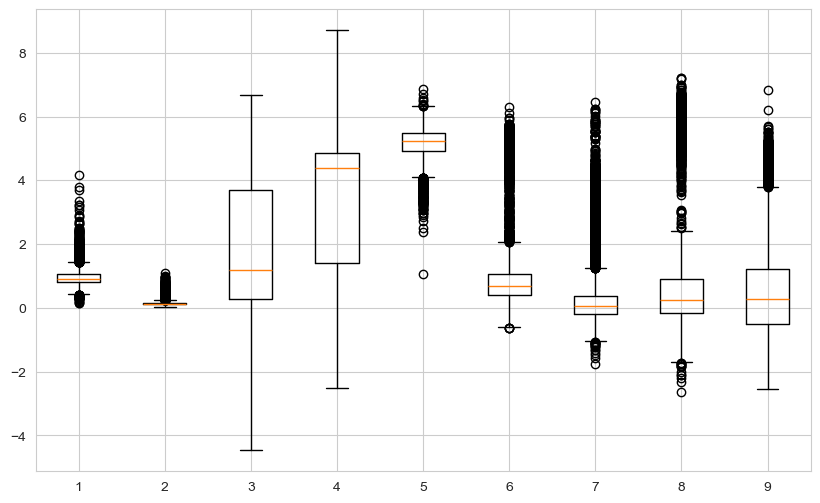

In [ ]:
fc_data = fc_data.drop(index= to_drop)
plt.figure(figsize=(10, 6))
plt.boxplot(fc_data)
plt.show()

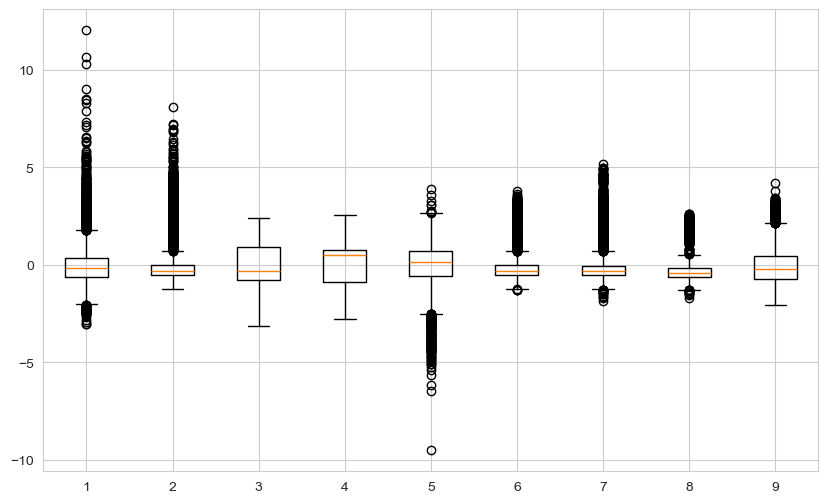

In [ ]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
data_std = std.fit_transform(fc_data)
data_std = pd.DataFrame(data_std, index=fc_data.index, columns=fc_data.columns)

plt.figure(figsize=(10, 6))
plt.boxplot(data_std)
plt.show()

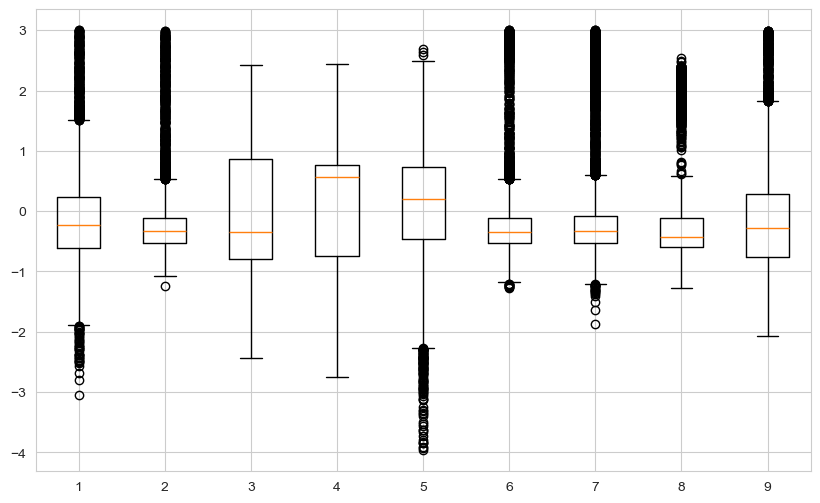

In [ ]:
critical_outliers_2 = data_std[data_std[((-4 < data_std) & (data_std < 3))].isna().any(1)]

data_std_min_outl = data_std.drop(index= list(critical_outliers_2.index)+[4138])

plt.figure(figsize=(10, 6))
plt.boxplot(data_std_min_outl)
plt.show()


Мне кажется можно оставить датафрейм в таком виде, так как сохранено около 90% наблюдений, при этом часть наиболее критических выбросов удалена!

#### Кластеризация


In [ ]:
def plot_tsne(data, n_iter=1000,
              perplexity=40, color=None):

    pca = PCA().fit(data)
    pca_embedding = pca.transform(data)


    tnse = TSNE(n_components=2, init=pca_embedding[:, :2], n_jobs=-1,
                n_iter=n_iter, perplexity=perplexity)
    tsne_embedding = tnse.fit_transform(pca_embedding)

    sns.scatterplot(x=tsne_embedding[:, 0],
                    y=tsne_embedding[:, 1],
                    hue=color, palette="colorblind")
    plt.xlabel("$TSNE_1$", fontsize=18)
    plt.ylabel("$TSNE_2$", fontsize=18)


    return tsne_embedding

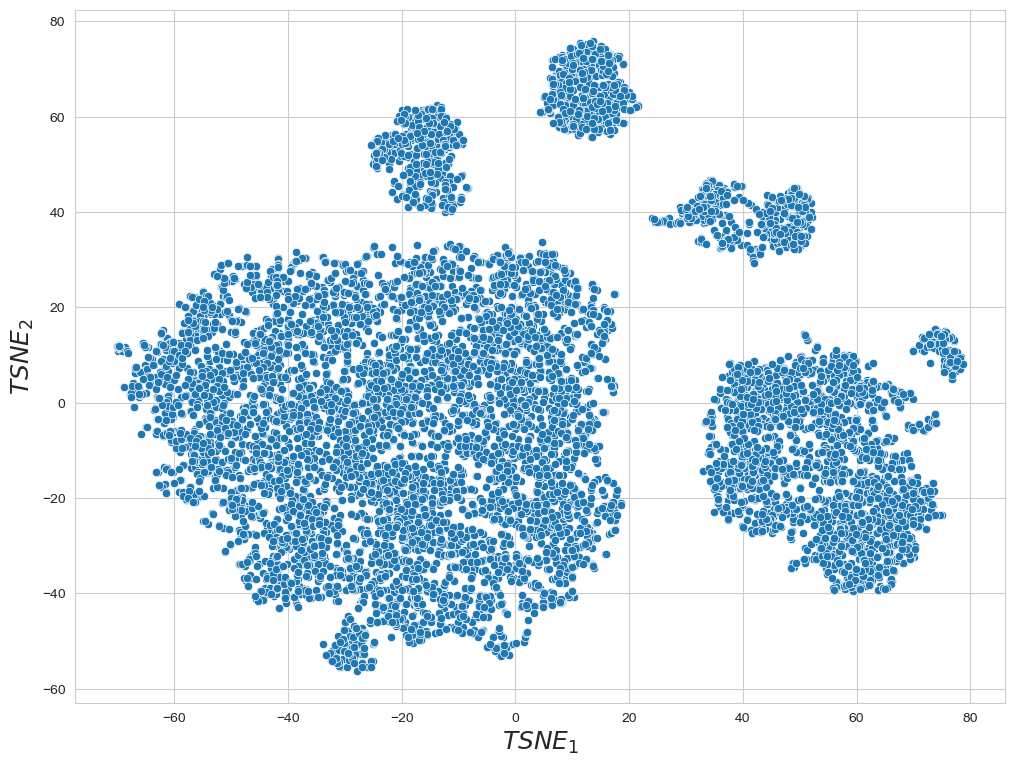

In [ ]:
tsne_res = plot_tsne(data_std_min_outl)

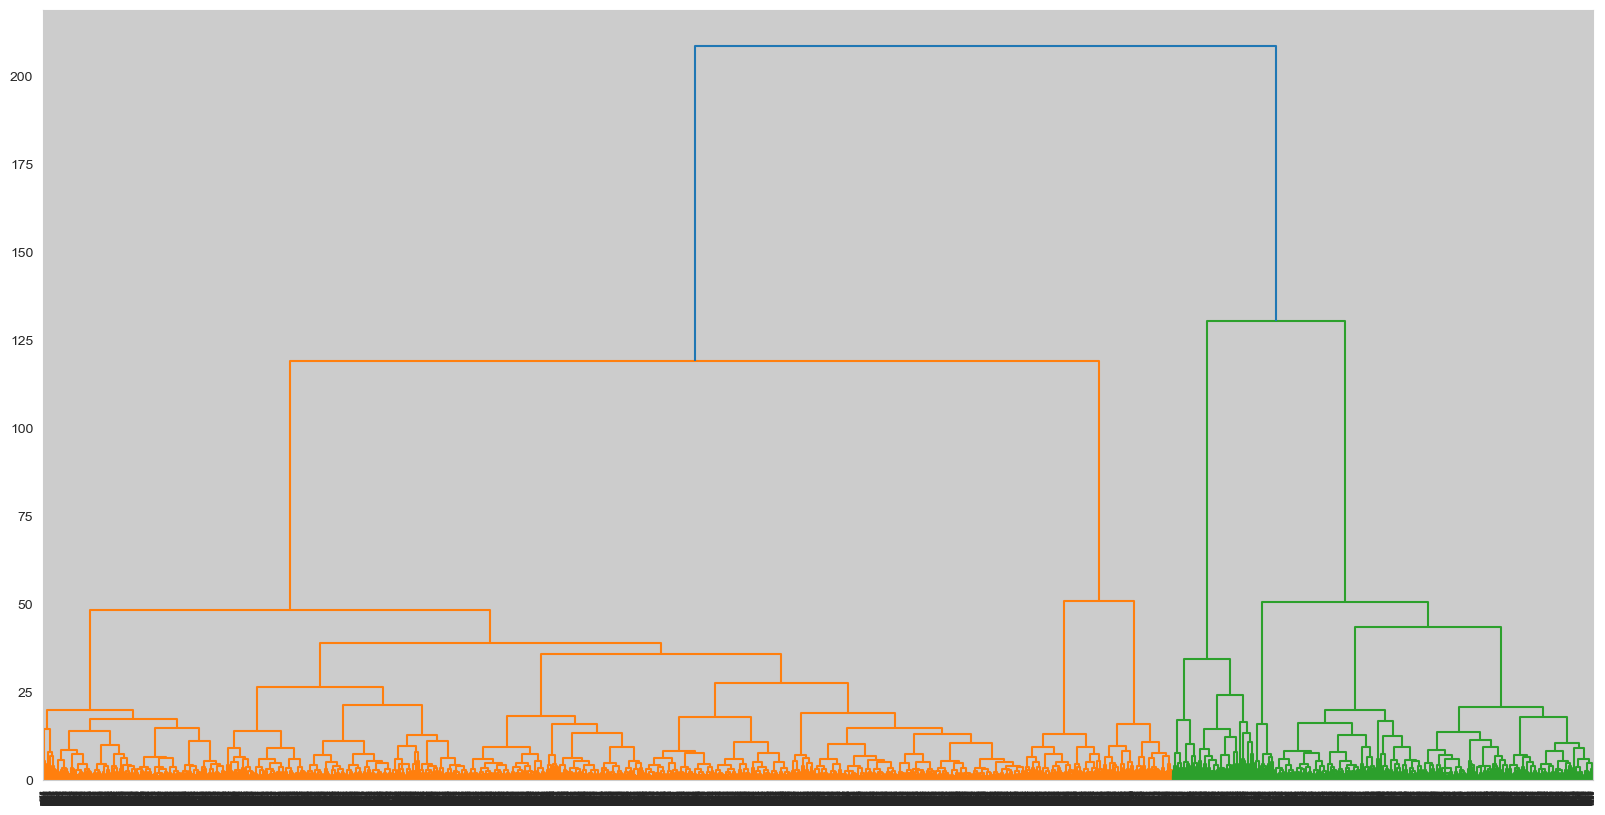

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
plt.figure(figsize=(20,10))
linkage_ = linkage(data_std_min_outl, method='ward')
dendrogram_ = dendrogram(linkage_)

In [ ]:
algorithm_selection(data_std_min_outl, n_clusters=4, algorithms=algo)

,linkage,silhouette
0,average,0.518186
1,average,0.471500
2,single,0.199025
3,single,0.199025
4,complete,0.473247
5,complete,0.464783


100%|██████████| 5/5 [00:11<00:00,  2.28s/it]


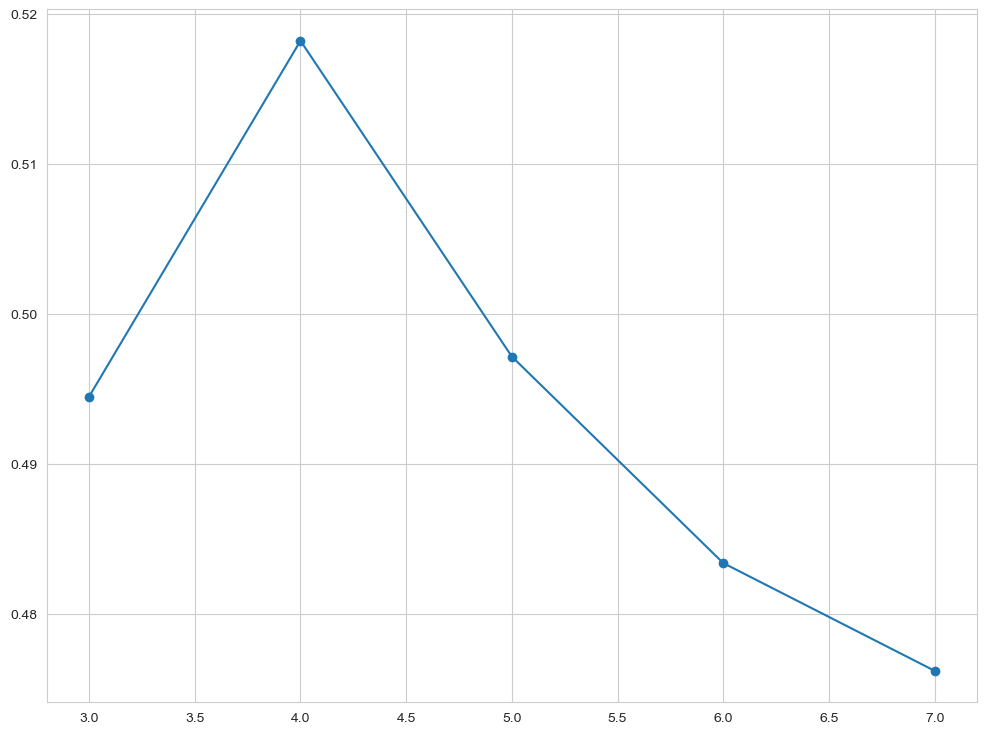

In [ ]:
silhouette = []
for i in tqdm(range(3,8)):
    agg = AgglomerativeClustering(n_clusters=i, linkage='average').fit(data_std_min_outl)
    labels = agg.labels_
    score = silhouette_score(data_std_min_outl, labels)
    silhouette.append(score)

plt.plot(range(3,8), silhouette, marker='o')

In [ ]:
agg = AgglomerativeClustering(n_clusters=4, linkage='average').fit(data_std_min_outl)
labels = agg.labels_

<Axes: >

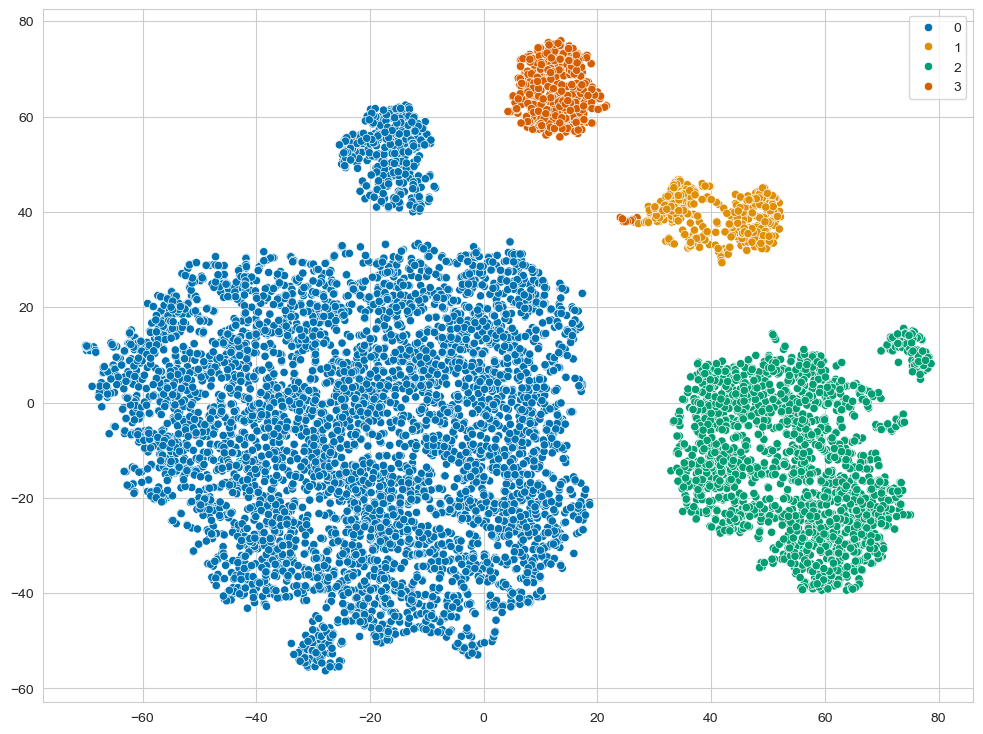

In [ ]:
sns.scatterplot(x=tsne_res[:, 0],
                    y=tsne_res[:, 1],
                    hue=labels, palette="colorblind")

## DBSCAN

In [ ]:
def dbscan_clustering(eps_range, X):
    eps_range = eps_range
    silhouette = []
    clusters = []
    for i in tqdm(eps_range):
        dbscan = DBSCAN(eps=i).fit(X)
        labels = dbscan.labels_
        uniq_labels = np.unique(labels)
        n_clusters = len(uniq_labels[uniq_labels != -1])
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = 0
        silhouette.append(score)
        clusters.append(n_clusters)

    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.plot(eps_range, silhouette, marker='o', color=color)
    ax1.set_xlabel('eps')
    ax1.set_ylabel('silhouette', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()

    color = 'tab:blue'
    ax2.plot(eps_range, clusters, marker='o', color=color)
    ax2.set_ylabel('n_clusters', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.show()

100%|██████████| 13/13 [00:26<00:00,  2.03s/it]


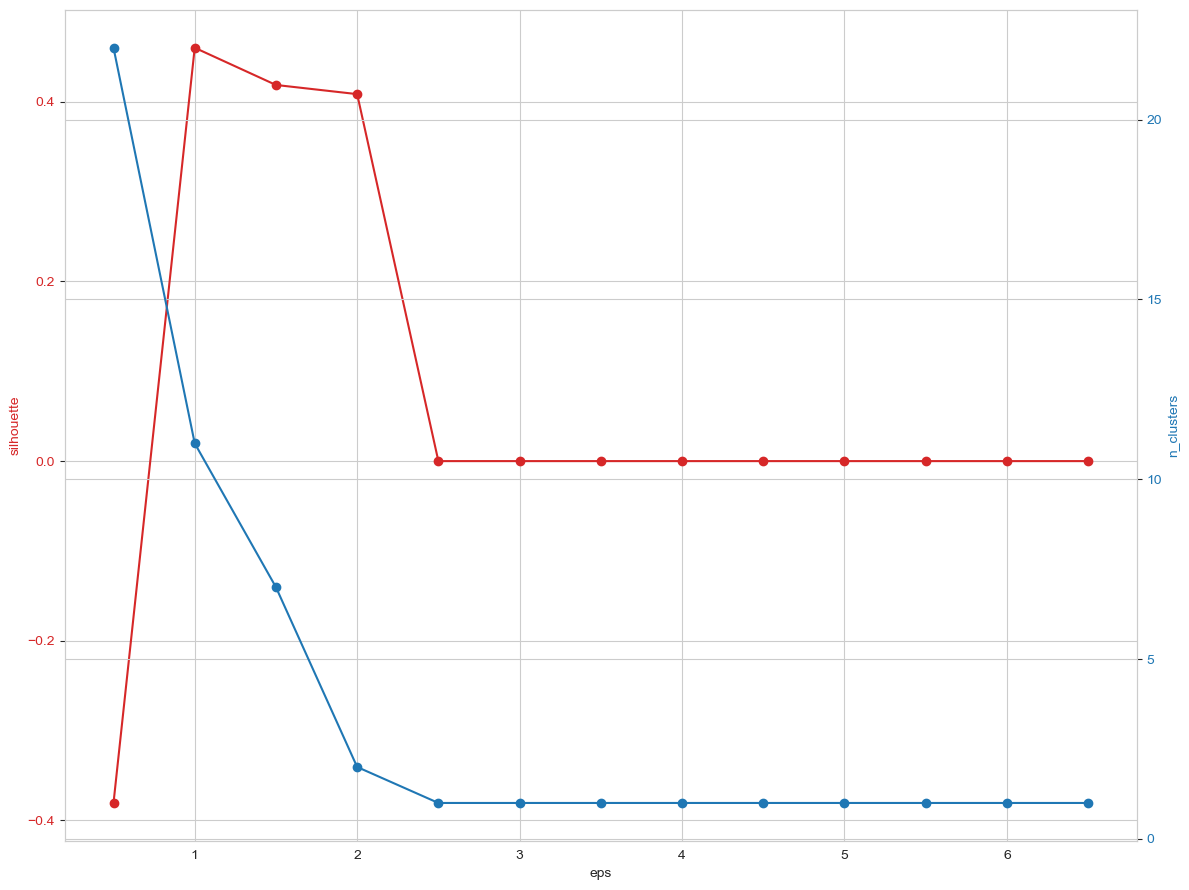

In [ ]:
eps_range = np.arange(0.5,7,0.5)
dbscan_clustering(eps_range, data_std_min_outl)

100%|██████████| 8/8 [00:15<00:00,  1.94s/it]


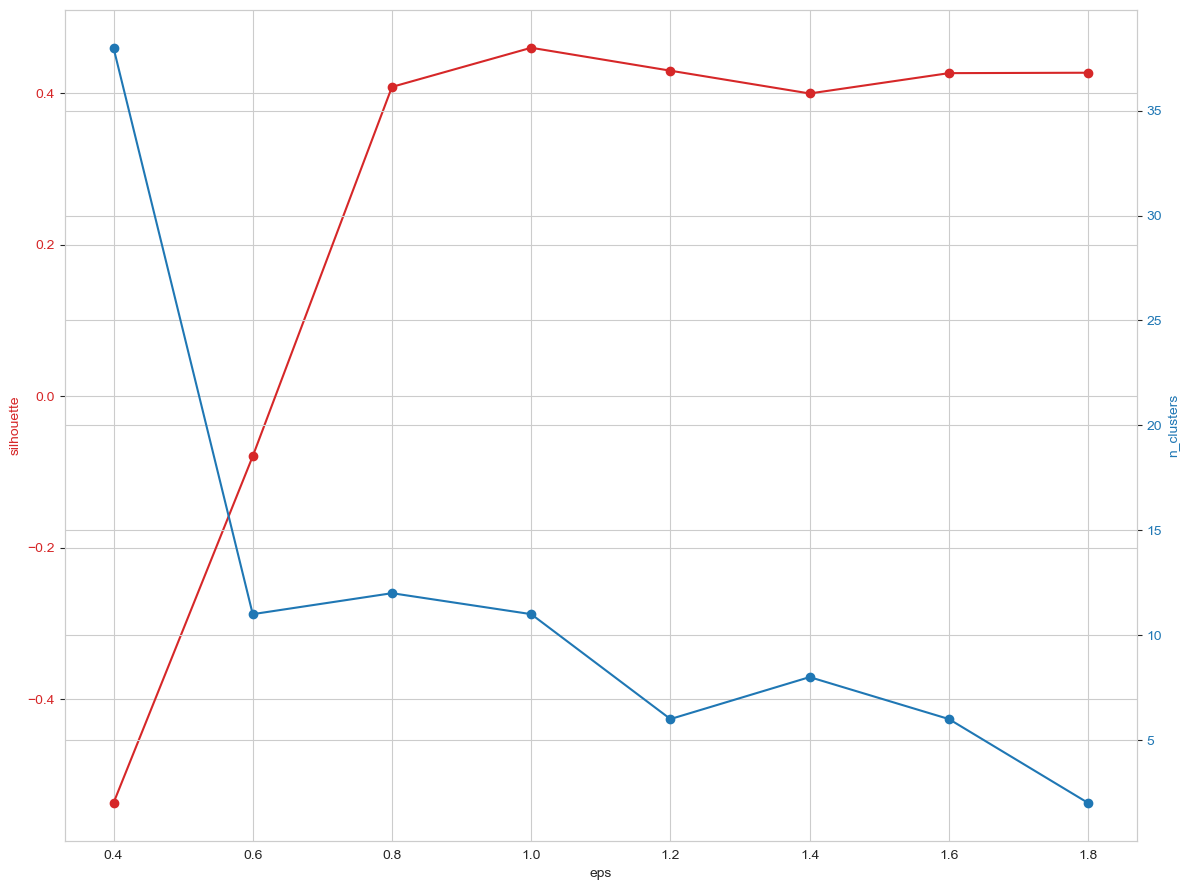

In [ ]:
eps_range = np.arange(0.4,2,0.2)
dbscan_clustering(eps_range, data_std_min_outl)

100%|██████████| 8/8 [00:17<00:00,  2.13s/it]


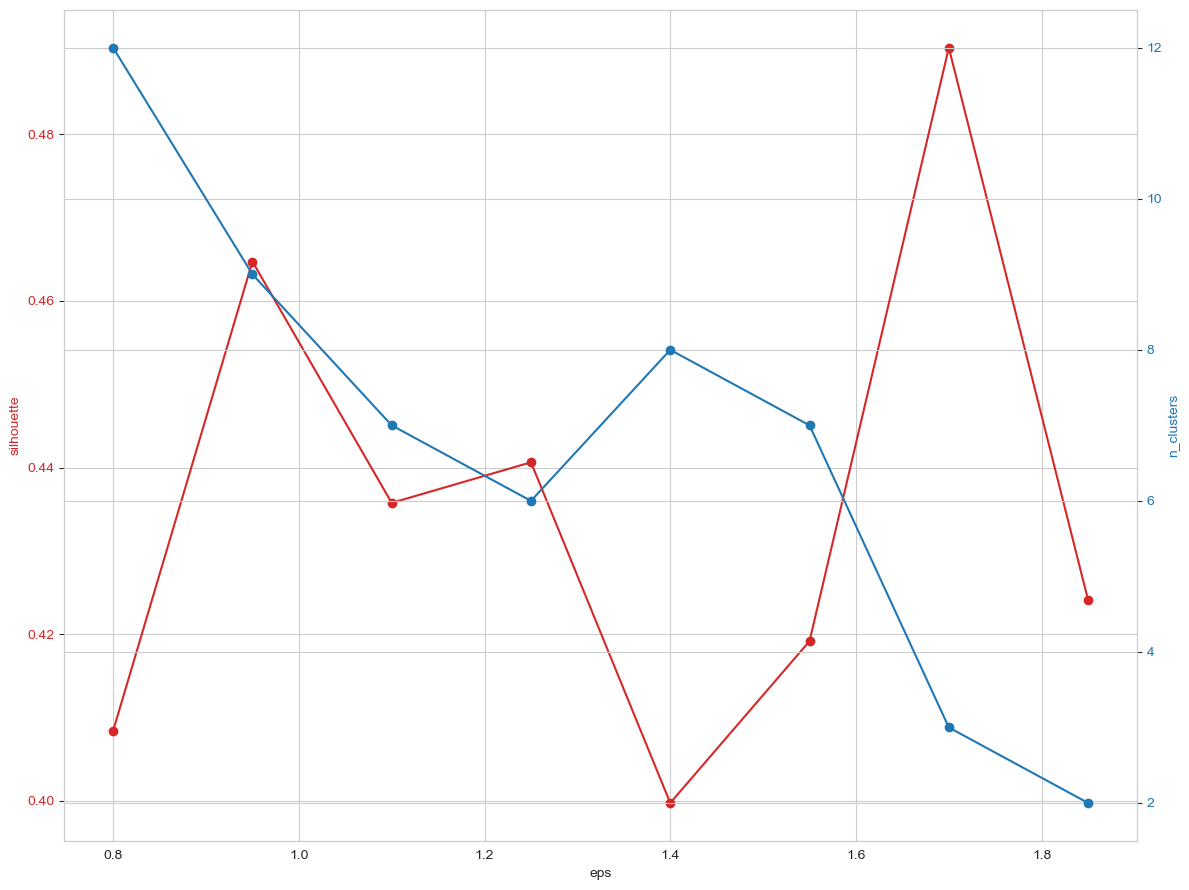

In [ ]:
eps_range = np.arange(0.8,1.9,0.15)
dbscan_clustering(eps_range, data_std_min_outl)

100%|██████████| 20/20 [00:50<00:00,  2.50s/it]


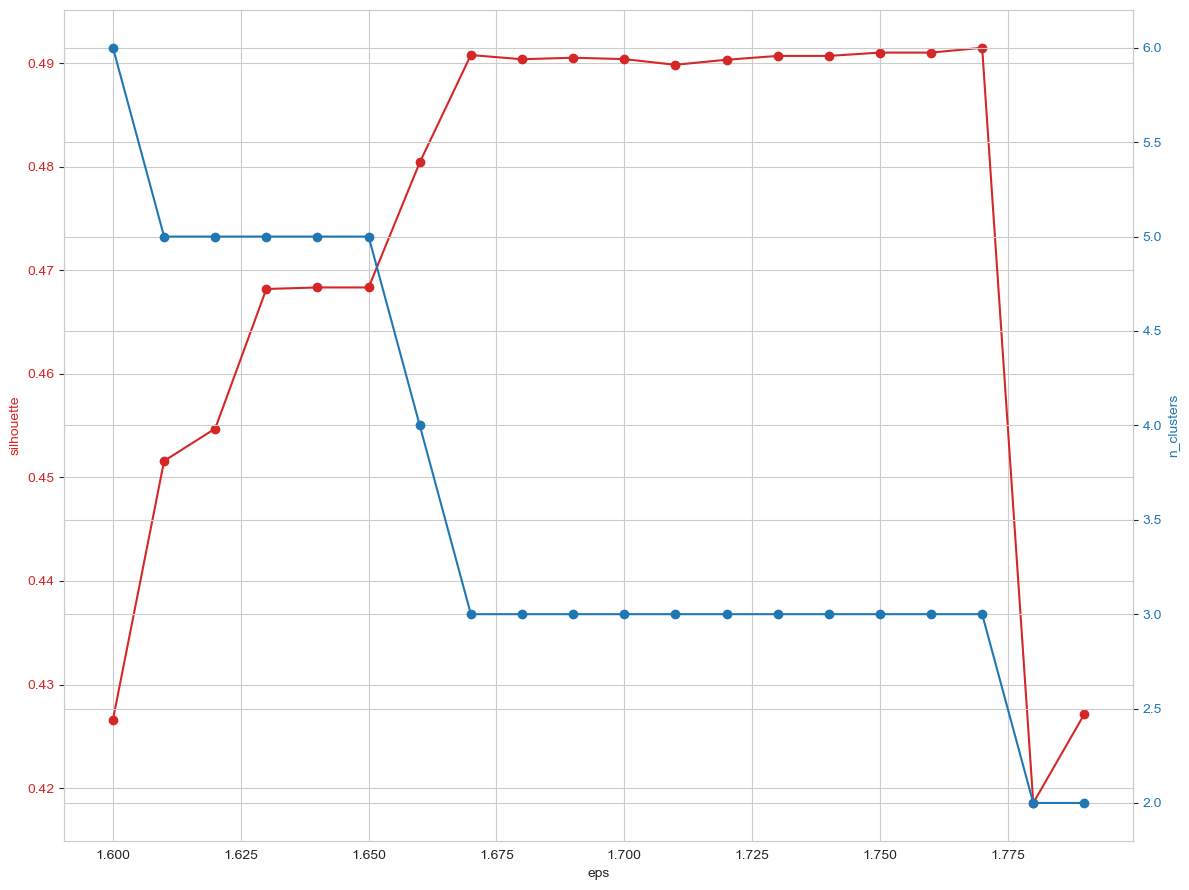

In [ ]:
eps_range = np.arange(1.6,1.8,0.01)
dbscan_clustering(eps_range, data_std_min_outl)

100%|██████████| 7/7 [00:18<00:00,  2.60s/it]


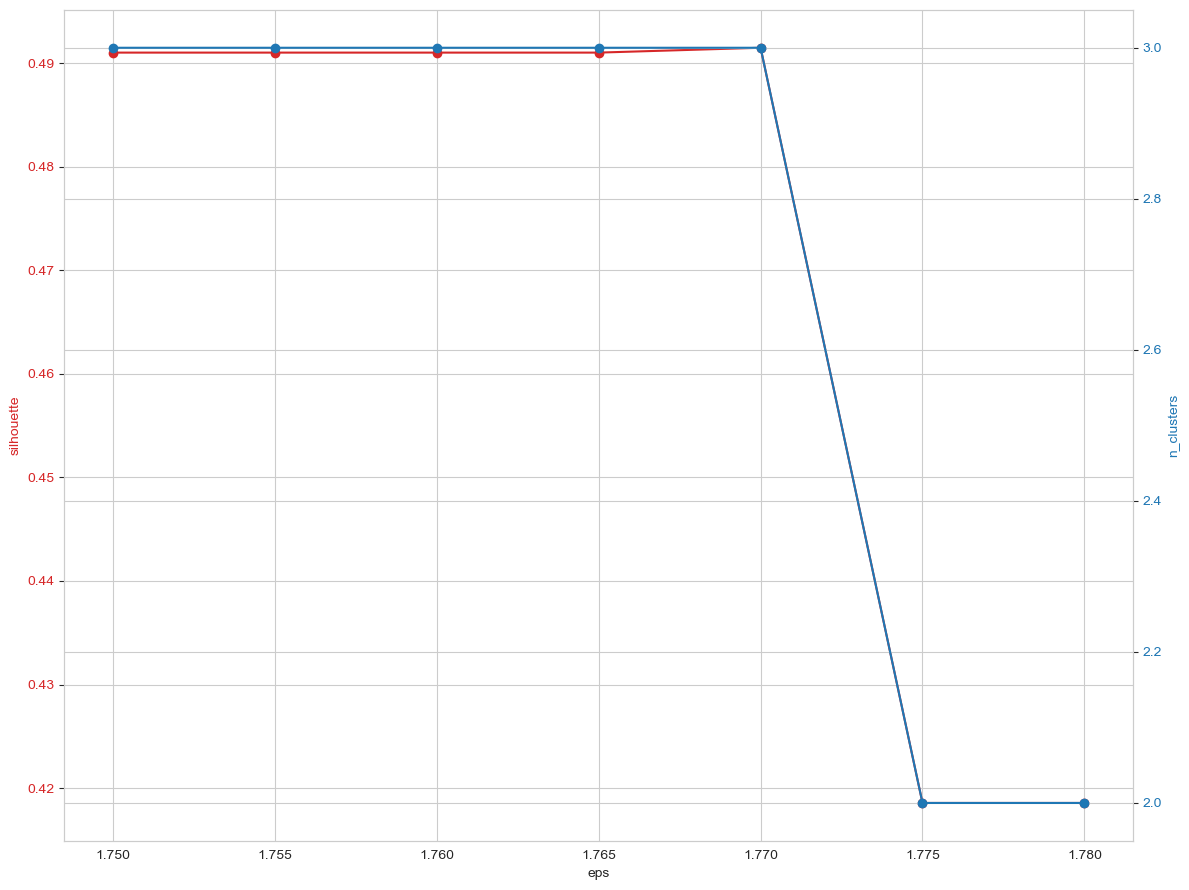

In [ ]:
eps_range = np.arange(1.75,1.78,0.005)
dbscan_clustering(eps_range, data_std_min_outl)

<Axes: >

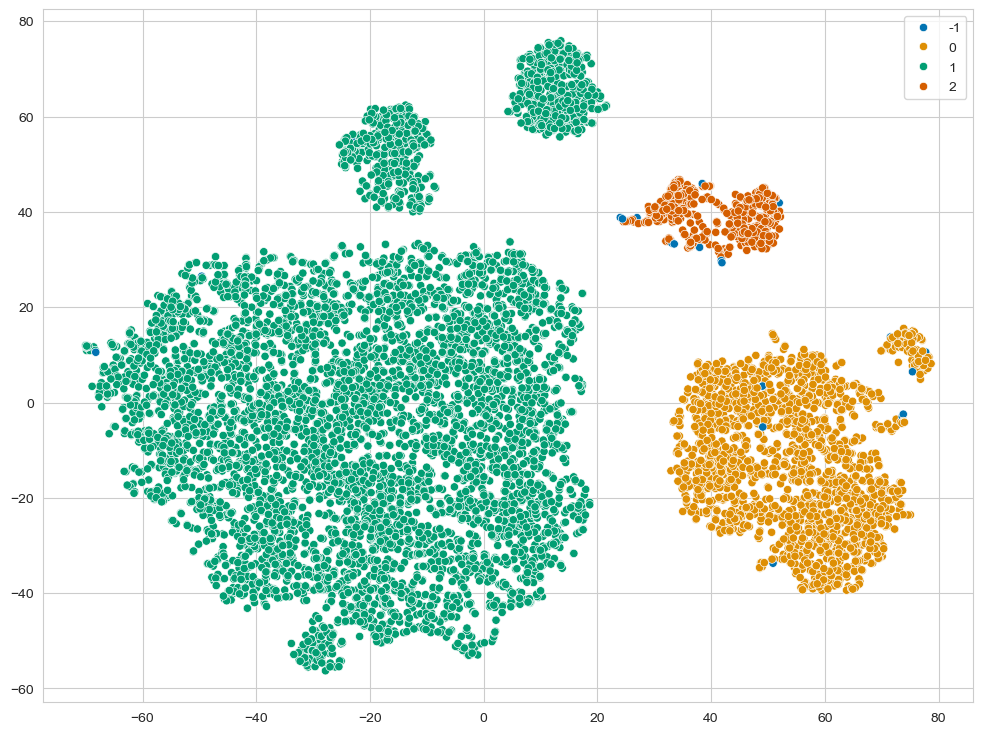

In [ ]:
dbscan = DBSCAN(eps = 1.77).fit(data_std_min_outl)
lab = dbscan.labels_
sns.scatterplot(x=tsne_res[:, 0],
                y=tsne_res[:, 1],
                hue=lab, palette="colorblind")

## KMeans

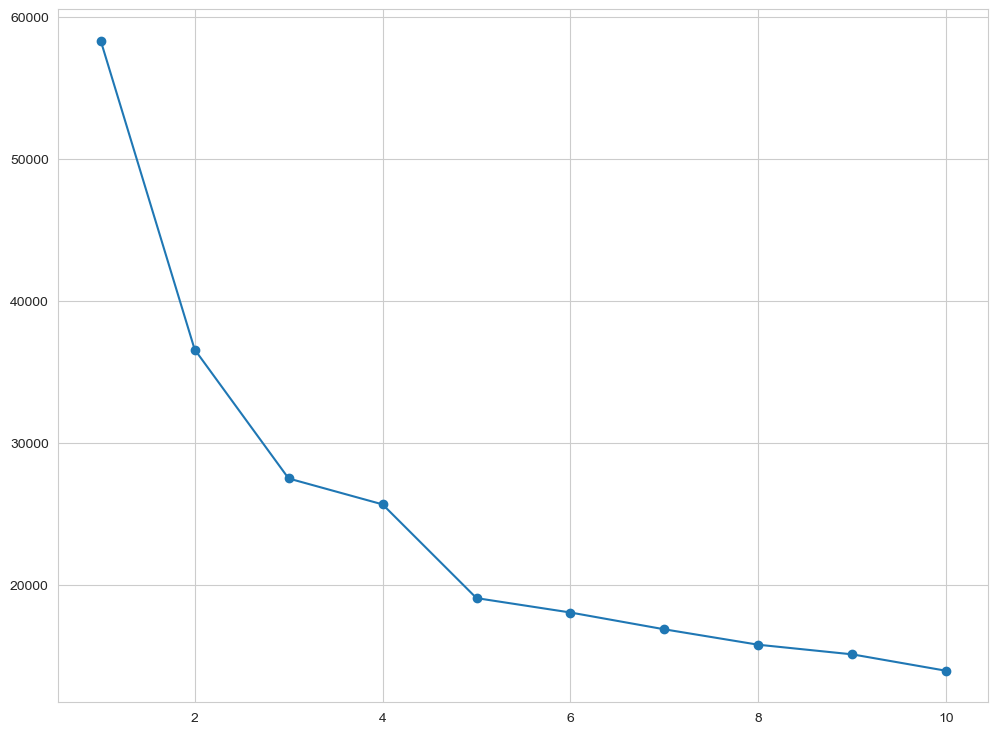

In [ ]:
inertia = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(data_std_min_outl)
    inertia_i = kmeans.inertia_
    inertia.append(inertia_i)

plt.plot(range(1,11), inertia, marker='o')

<Axes: >

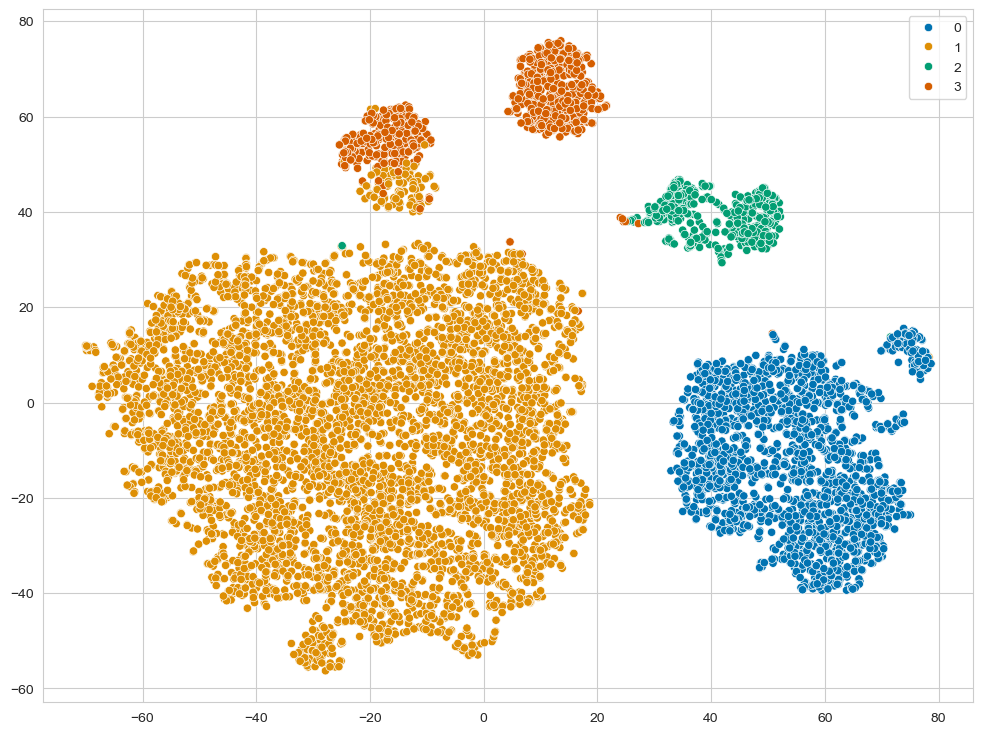

In [ ]:
k_m = KMeans(n_clusters=4).fit(data_std_min_outl)
lab = k_m.labels_

sns.scatterplot(x=tsne_res[:, 0],
                y=tsne_res[:, 1],
                hue=lab, palette="colorblind")

На мой взгляд иерархическая кластеризация лучше показывает себя при решении данной задачи

In [ ]:
agg = AgglomerativeClustering(n_clusters=4, linkage='average').fit(data_std_min_outl)
labels = agg.labels_

#### 3.3. Аннотация клеточных типов


Теперь когда мы подобрали хороший алгоритм кластеризации, можно аннотировать наши клетки. Для этого мы нарисуем t-SNE и покрасим точки в зависимости от интенсивности экспрессии поверхностных маркеров. В датасете присутствуют следующие типы клеток:

* B_cells
* T_cells
* Monocytes
* Other cells

Вам нужно будет выяснить, какие клетки экспрессируют определенные маркеры и присвоить каждому кластеру один из типов клеток.

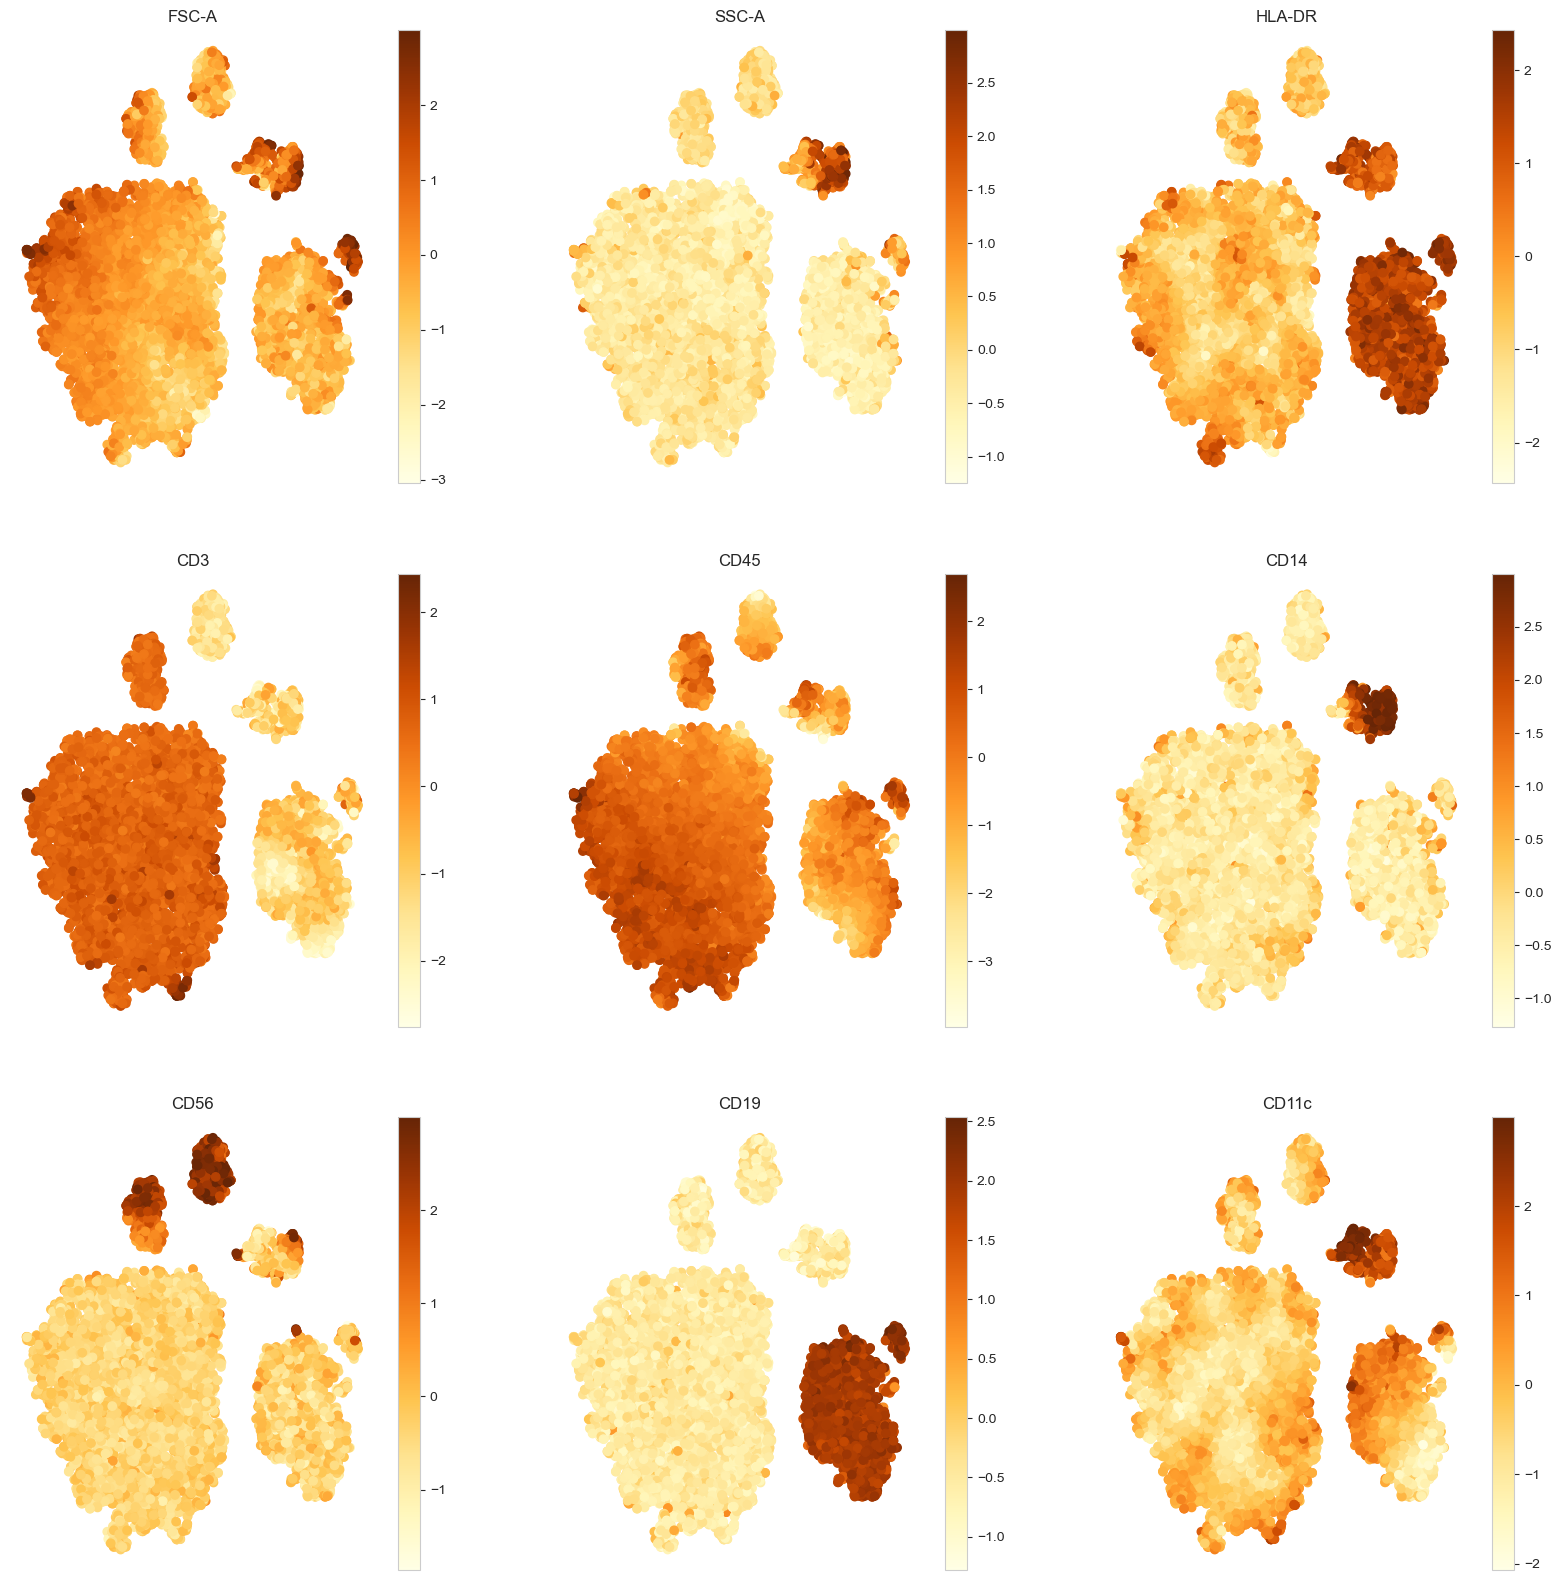

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
for col, ax in zip(data_std_min_outl.columns, axes.ravel()):
    scatter = ax.scatter(tsne_res[:, 0], tsne_res[:, 1],
                         c=data_std_min_outl[col], cmap="YlOrBr")
    fig.colorbar(scatter, ax=ax)
    ax.set_title(col)
    ax.grid(False)
    ax.axis("off")

B_cells: CD19

T_cells: CD3

Monocytes: CD14, HLA-DR.

Дальше дело за вами, нужно определить клеточный тип для каждого кластера и записать их как значения в словаре:

In [ ]:
cell_type_cluster_map = {0: "T_cells",
                         1: "Other cells",
                         2: "B_cells",
                         3: "Monocytes"}

In [ ]:
labeled_fc_data = data_std_min_outl.assign(Population=agg.labels_)
labeled_fc_data["Population"] = labeled_fc_data["Population"].map(cell_type_cluster_map)

Посчитайте, как распределены типы клеток:

In [ ]:
labeled_fc_data.Population.value_counts()

T_cells        6104
B_cells        1961
Monocytes       462
Other cells     460
Name: Population, dtype: int64

Сохраните ваши результаты в csv файл, мы сравним их с правильными ответами по метрике `f1_score(average="macro")`, которая хорошо подходит, даже если классы не сбалансированы.

In [ ]:
labeled_fc_data = labeled_fc_data.reset_index()
labeled_fc_data.to_csv(join(DATA_PATH, "labeled_fc_data.csv"), index=False)

#### 3.4. Атоматическая аннотация



Построить классификатор клеточных типов на основе размеченных данных.

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(join(DATA_PATH, "labeled_fc_data.csv"), index_col=0)#.dropna()


In [ ]:
labeled_fc_data.shape

(8987, 11)

In [ ]:
from sklearn.utils import resample

df_majority = df[df.Population=='T_cells']
df_majority = resample(df_majority, replace=False,
                                 n_samples=2000, random_state=42)

df_minirity = df[df.Population=='Monocytes']
df_minirity1 = resample(df_minirity, replace=True,
                        n_samples=1000, random_state=42)

df_minirity = df[df.Population=='Other cells']
df_minirity2 = resample(df_minirity, replace=True,
                        n_samples=1000, random_state=42)

df = pd.concat([df_majority, df_minirity1, df_minirity2, df[df.Population=='B_cells']])
df.shape

(5961, 10)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Population']), df['Population'], test_size=0.25, random_state=42)
X_train.shape

(4470, 9)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

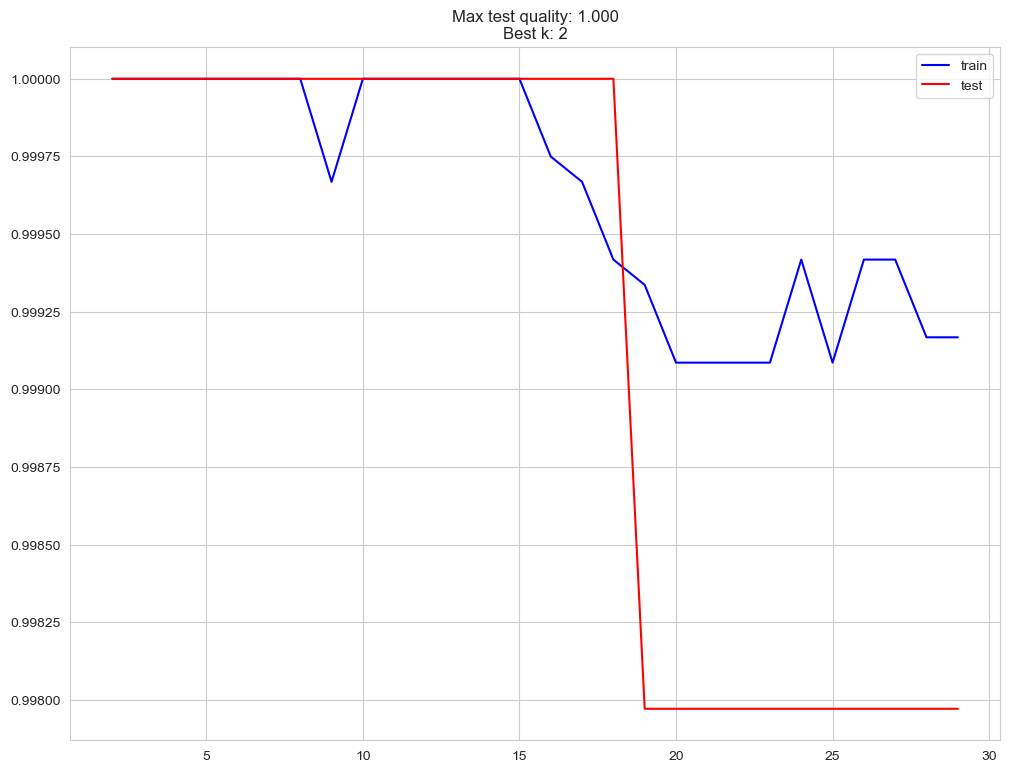

In [ ]:
neighbors = range(2, 30)
f1_score_train = []
f1_score_test = []
kk = list(range(2,30))
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    y_pred_train = knn.predict(X_train)
    f1_score_train.append(f1_score(y_pred_train, y_train, average="macro"))
    f1_score_test.append(f1_score(y_pred, y_test, average="macro"))

plt.plot(neighbors, f1_score_train, color='blue', label='train')
plt.plot(neighbors, f1_score_test, color='red', label='test')
plt.title("Max test quality: {:.3f}\nBest k: {}".format(max(f1_score_test), kk[np.argmax(f1_score_test)]))
plt.legend();